In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make plots look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All libraries loaded ✓")
print(f"pandas:     {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn:    {sns.__version__}")
print(f"numpy:      {np.__version__}")

All libraries loaded ✓
pandas:     3.0.3
matplotlib: 3.10.9
seaborn:    0.13.2
numpy:      2.4.6


In [2]:
# Load ratings
ratings = pd.read_csv(
    "../data/ratings.dat",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

# Load movies
movies = pd.read_csv(
    "../data/movies.dat",
    sep="|",
    encoding="latin-1",
    usecols=[0, 1],
    names=["movieId", "title"]
)

print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape:  {movies.shape}")
print()
print(ratings.head(3))

Ratings shape: (100000, 4)
Movies shape:  (1682, 2)

   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116


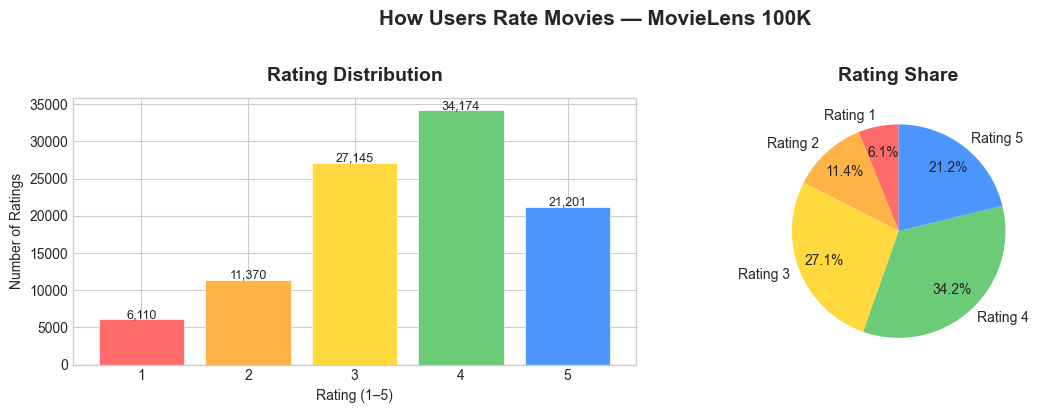


Rating breakdown:
  ★1   6,110 ratings  (6.1%)
  ★2  11,370 ratings  (11.4%)
  ★3  27,145 ratings  (27.1%)
  ★4  34,174 ratings  (34.2%)
  ★5  21,201 ratings  (21.2%)

Mean rating: 3.53
Median:      4


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — count of each rating value
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, 
            color=['#ff6b6b','#ffb347','#ffd93d','#6bcb77','#4d96ff'],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Rating (1–5)')
axes[0].set_ylabel('Number of Ratings')
for i, (val, count) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(val, count + 200, f'{count:,}', ha='center', fontsize=9)

# Right — percentage breakdown
axes[1].pie(rating_counts.values, labels=[f'Rating {i}' for i in rating_counts.index],
            colors=['#ff6b6b','#ffb347','#ffd93d','#6bcb77','#4d96ff'],
            autopct='%1.1f%%', startangle=90, pctdistance=0.75)
axes[1].set_title('Rating Share', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('How Users Rate Movies — MovieLens 100K', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRating breakdown:")
for rating, count in rating_counts.items():
    pct = count / len(ratings) * 100
    print(f"  ★{rating}  {count:>6,} ratings  ({pct:.1f}%)")
print(f"\nMean rating: {ratings['rating'].mean():.2f}")
print(f"Median:      {ratings['rating'].median():.0f}")

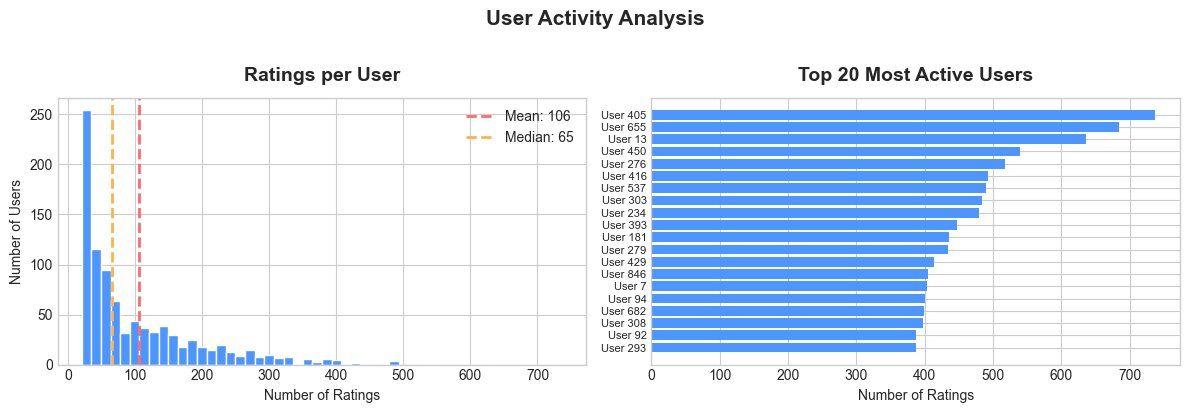

User activity stats:
  Most active user:   737 ratings
  Least active user:  20 ratings
  Mean per user:      106.0 ratings
  Median per user:    65 ratings

Users with fewer than 20 ratings: 0 (0.0%)
Users with more than 200 ratings: 148 (15.7%)


In [5]:
user_activity = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — histogram of ratings per user
axes[0].hist(user_activity.values, bins=50, color='#4d96ff', edgecolor='white')
axes[0].set_title('Ratings per User', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(user_activity.mean(), color='#ff6b6b', linestyle='--', linewidth=2, label=f'Mean: {user_activity.mean():.0f}')
axes[0].axvline(user_activity.median(), color='#ffb347', linestyle='--', linewidth=2, label=f'Median: {user_activity.median():.0f}')
axes[0].legend()

# Right — top 20 most active users
top_users = user_activity.head(20)
axes[1].barh(range(20), top_users.values, color='#4d96ff')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'User {u}' for u in top_users.index], fontsize=8)
axes[1].set_title('Top 20 Most Active Users', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()

plt.suptitle('User Activity Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

print("User activity stats:")
print(f"  Most active user:   {user_activity.max()} ratings")
print(f"  Least active user:  {user_activity.min()} ratings")
print(f"  Mean per user:      {user_activity.mean():.1f} ratings")
print(f"  Median per user:    {user_activity.median():.0f} ratings")
print(f"\nUsers with fewer than 20 ratings: {(user_activity < 20).sum()} ({(user_activity < 20).mean()*100:.1f}%)")
print(f"Users with more than 200 ratings: {(user_activity > 200).sum()} ({(user_activity > 200).mean()*100:.1f}%)")

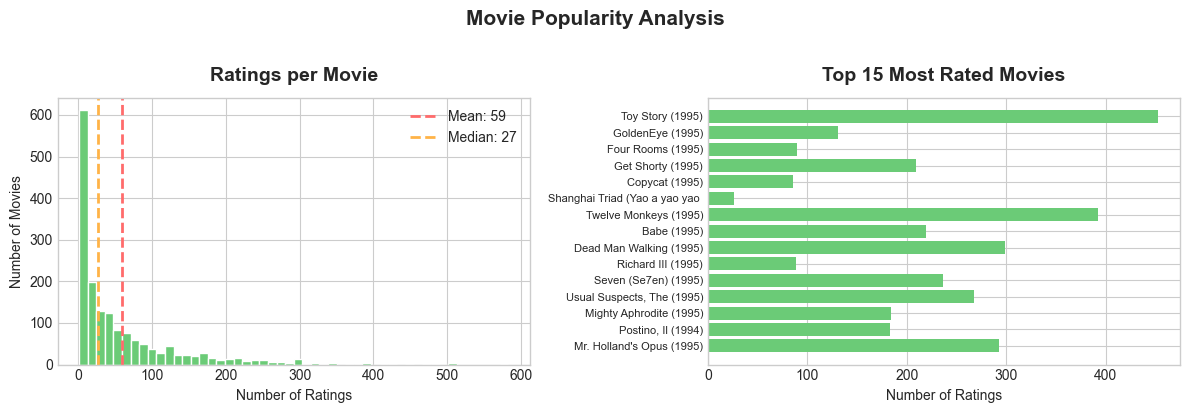

Movie activity stats:
  Most rated movie:    583 ratings — Toy Story (1995)
  Least rated movie:   1 ratings
  Mean per movie:      59.5 ratings
  Median per movie:    27 ratings

Movies with fewer than 10 ratings: 530 (31.5%)
Movies with fewer than 5 ratings:  333 (19.8%)


In [6]:
movie_activity = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
movie_avg = ratings.groupby('movieId')['rating'].mean()

# Merge with titles
movie_stats = pd.DataFrame({
    'count': movie_activity,
    'avg_rating': movie_avg
}).merge(movies, on='movieId')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — histogram of ratings per movie
axes[0].hist(movie_activity.values, bins=50, color='#6bcb77', edgecolor='white')
axes[0].set_title('Ratings per Movie', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(movie_activity.mean(), color='#ff6b6b', linestyle='--', 
                linewidth=2, label=f'Mean: {movie_activity.mean():.0f}')
axes[0].axvline(movie_activity.median(), color='#ffb347', linestyle='--', 
                linewidth=2, label=f'Median: {movie_activity.median():.0f}')
axes[0].legend()

# Right — top 15 most rated movies
top_movies = movie_stats.head(15)
axes[1].barh(range(15), top_movies['count'].values, color='#6bcb77')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(
    [t[:30] for t in top_movies['title'].values], fontsize=8)
axes[1].set_title('Top 15 Most Rated Movies', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()

plt.suptitle('Movie Popularity Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/movie_activity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Movie activity stats:")
print(f"  Most rated movie:    {movie_activity.max()} ratings — {movie_stats.iloc[0]['title']}")
print(f"  Least rated movie:   {movie_activity.min()} ratings")
print(f"  Mean per movie:      {movie_activity.mean():.1f} ratings")
print(f"  Median per movie:    {movie_activity.median():.0f} ratings")
print(f"\nMovies with fewer than 10 ratings: {(movie_activity < 10).sum()} ({(movie_activity < 10).mean()*100:.1f}%)")
print(f"Movies with fewer than 5 ratings:  {(movie_activity < 5).sum()} ({(movie_activity < 5).mean()*100:.1f}%)")

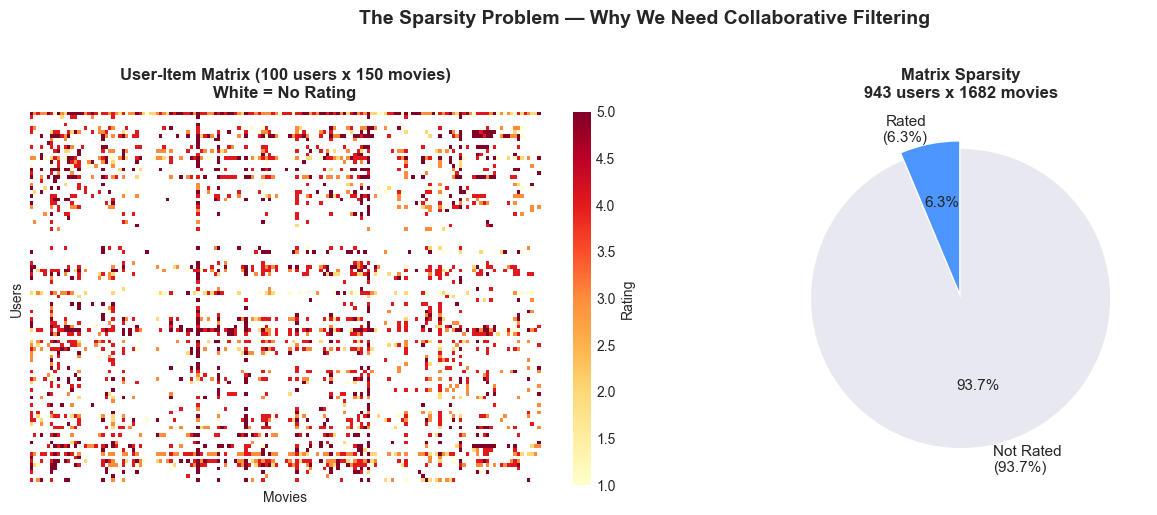

Total possible ratings: 1,586,126
Actual ratings:         100,000
Missing ratings:        1,486,126
Sparsity:               93.7%

This means your model needs to predict values for
1,486,126 unknown user-movie pairs.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — sparsity heatmap (sampled for visibility)
sample_users  = sorted(ratings['userId'].unique())[:100]
sample_movies = sorted(ratings['movieId'].unique())[:150]

matrix = ratings[
    ratings['userId'].isin(sample_users) &
    ratings['movieId'].isin(sample_movies)
].pivot_table(index='userId', columns='movieId', values='rating')
matrix_reindexed = matrix.reindex(index=sample_users, columns=sample_movies)

sns.heatmap(matrix_reindexed, ax=axes[0],
            cmap='YlOrRd', cbar_kws={'label': 'Rating'},
            xticklabels=False, yticklabels=False)
axes[0].set_title('User-Item Matrix (100 users x 150 movies)\nWhite = No Rating',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Movies')
axes[0].set_ylabel('Users')

# Right — filled vs empty breakdown
total_possible = ratings['userId'].nunique() * ratings['movieId'].nunique()
total_filled   = len(ratings)
total_empty    = total_possible - total_filled

axes[1].pie(
    [total_filled, total_empty],
    labels=['Rated\n(6.3%)', 'Not Rated\n(93.7%)'],
    colors=['#4d96ff', '#e8e8f0'],
    explode=[0.05, 0],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Matrix Sparsity\n943 users x 1682 movies',
                  fontsize=12, fontweight='bold', pad=10)

plt.suptitle('The Sparsity Problem — Why We Need Collaborative Filtering',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

sparsity = 1 - (total_filled / total_possible)
print(f"Total possible ratings: {total_possible:,}")
print(f"Actual ratings:         {total_filled:,}")
print(f"Missing ratings:        {total_empty:,}")
print(f"Sparsity:               {sparsity*100:.1f}%")
print(f"\nThis means your model needs to predict values for")
print(f"{total_empty:,} unknown user-movie pairs.")

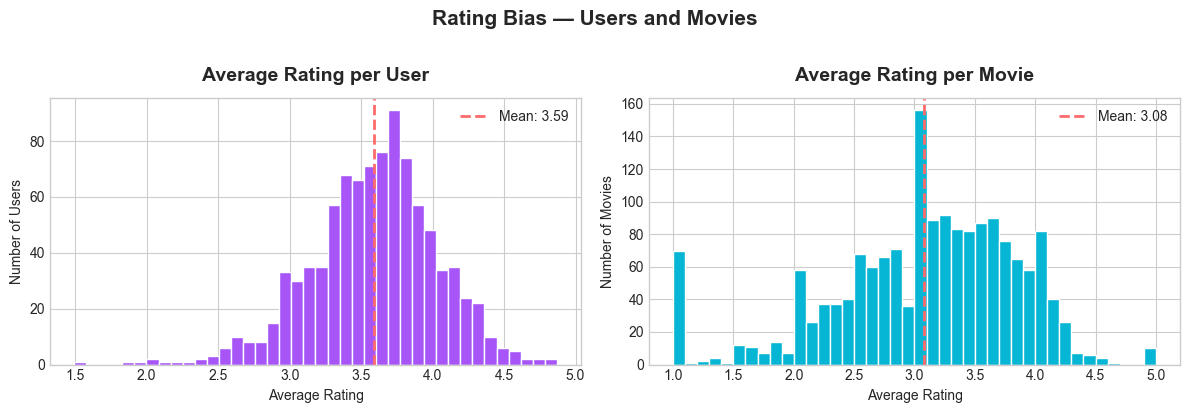

User bias stats:
  Harshest user avg:  1.49
  Most generous avg:  4.87
  Std deviation:      0.45

Movie bias stats:
  Lowest rated movie avg:   1.00
  Highest rated movie avg:  5.00
  Std deviation:            0.78


In [8]:
user_avg = ratings.groupby('userId')['rating'].mean()
movie_avg_rating = ratings.groupby('movieId')['rating'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — distribution of average rating per user
axes[0].hist(user_avg.values, bins=40, color='#a855f7', edgecolor='white')
axes[0].axvline(user_avg.mean(), color='#ff6b6b', linestyle='--',
                linewidth=2, label=f'Mean: {user_avg.mean():.2f}')
axes[0].set_title('Average Rating per User', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Users')
axes[0].legend()

# Right — distribution of average rating per movie
axes[1].hist(movie_avg_rating.values, bins=40, color='#06b6d4', edgecolor='white')
axes[1].axvline(movie_avg_rating.mean(), color='#ff6b6b', linestyle='--',
                linewidth=2, label=f'Mean: {movie_avg_rating.mean():.2f}')
axes[1].set_title('Average Rating per Movie', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Number of Movies')
axes[1].legend()

plt.suptitle('Rating Bias — Users and Movies', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("User bias stats:")
print(f"  Harshest user avg:  {user_avg.min():.2f}")
print(f"  Most generous avg:  {user_avg.max():.2f}")
print(f"  Std deviation:      {user_avg.std():.2f}")
print(f"\nMovie bias stats:")
print(f"  Lowest rated movie avg:   {movie_avg_rating.min():.2f}")
print(f"  Highest rated movie avg:  {movie_avg_rating.max():.2f}")
print(f"  Std deviation:            {movie_avg_rating.std():.2f}")

In [9]:
global_mean = ratings['rating'].mean()
total_users = ratings['userId'].nunique()
total_movies = ratings['movieId'].nunique()
total_ratings = len(ratings)
sparsity = 1 - (total_ratings / (total_users * total_movies))

print("=" * 55)
print("   EDA SUMMARY — MovieLens 100K")
print("=" * 55)

print(f"""
DATASET
  Users:            {total_users:,}
  Movies:           {total_movies:,}
  Ratings:          {total_ratings:,}
  Global mean:      {global_mean:.2f} / 5.0

SPARSITY
  Matrix size:      {total_users * total_movies:,} possible ratings
  Filled:           {total_ratings:,} ({(1-sparsity)*100:.1f}%)
  Empty:            {total_users * total_movies - total_ratings:,} (93.7%)
  → Model must predict values for 1.48M unknown pairs

RATING DISTRIBUTION
  Most common:      Rating 4 ({ratings[ratings.rating==4].shape[0]:,} ratings)
  Skew:             Positive — users rate generously

USER ACTIVITY  
  Range:            {ratings.groupby('userId').rating.count().min()}–{ratings.groupby('userId').rating.count().max()} ratings per user
  Median:           65 ratings per user
  Power users:      148 users with 200+ ratings (15.7%)
  Cold start:       No users with fewer than 20 ratings

MOVIE POPULARITY (Long Tail)
  Most rated:       Toy Story — 583 ratings
  Least rated:      1 rating
  Sparse movies:    530 movies with fewer than 10 ratings (31.5%)
  Cold start:       333 movies with fewer than 5 ratings (19.8%)

BIAS
  User avg range:   1.49 – 4.87 (std: 0.45)
  Movie avg range:  1.00 – 5.00 (std: 0.78)
  → SVD bias terms needed to correct for individual tendencies

MODELLING DECISION
  → Use SVD collaborative filtering
  → Reason 1: 93.7% sparsity requires matrix factorisation
  → Reason 2: User and movie biases require explicit bias terms
  → Reason 3: No content features available — pure interaction data
  → Baseline: Global mean predictor (RMSE target: beat ~1.0)
  → Target RMSE: < 0.95 with 5-fold cross-validation
""")
print("=" * 55)

   EDA SUMMARY — MovieLens 100K

DATASET
  Users:            943
  Movies:           1,682
  Ratings:          100,000
  Global mean:      3.53 / 5.0

SPARSITY
  Matrix size:      1,586,126 possible ratings
  Filled:           100,000 (6.3%)
  Empty:            1,486,126 (93.7%)
  → Model must predict values for 1.48M unknown pairs

RATING DISTRIBUTION
  Most common:      Rating 4 (34,174 ratings)
  Skew:             Positive — users rate generously

USER ACTIVITY  
  Range:            20–737 ratings per user
  Median:           65 ratings per user
  Power users:      148 users with 200+ ratings (15.7%)
  Cold start:       No users with fewer than 20 ratings

MOVIE POPULARITY (Long Tail)
  Most rated:       Toy Story — 583 ratings
  Least rated:      1 rating
  Sparse movies:    530 movies with fewer than 10 ratings (31.5%)
  Cold start:       333 movies with fewer than 5 ratings (19.8%)

BIAS
  User avg range:   1.49 – 4.87 (std: 0.45)
  Movie avg range:  1.00 – 5.00 (std: 0.78)
  → S